# Demo 2 - Full Real Pipeline

This notebook demonstrates the current end-to-end library-backed workflow for a real re-entry case.

It starts from a NORAD catalog ID and an analysis window, then uses the library to:

1. Load the best TLE from cache or Space-Track
2. Propagate the orbit into a ground track using Skyfield
3. Break the propagated path into overlapping download boxes
4. Convert those boxes into download requests
5. Query candidate station inventory within each box
6. Filter stations by minimum great-circle distance to the propagated track
7. Download waveform data only for stations that survive the physical corridor filter
8. Visualize the resulting geometry and station coverage

This demo is meant to validate the current library-backed workflow before later optimizations such as merged waveform requests across overlapping boxes.

## Load space track env credentials

In [1]:
from pathlib import Path
from dotenv import load_dotenv
import os

repo_root = Path().resolve().parent
env_path = repo_root / ".env"

print("Using .env at:", env_path)
print("Exists:", env_path.exists())

load_dotenv(env_path, override=True)

print("SPACETRACK_USER exists:", os.environ.get("SPACETRACK_USER") is not None)
print("SPACETRACK_PASS exists:", os.environ.get("SPACETRACK_PASS") is not None)

Using .env at: C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\.env
Exists: True
SPACETRACK_USER exists: True
SPACETRACK_PASS exists: True


In [2]:
%load_ext autoreload
%autoreload 2

## Imports

In [3]:
from datetime import datetime, timezone
from pathlib import Path
import json

from reentry_seismo.io import get_run_folder
from reentry_seismo.track import build_track_from_norad
from reentry_seismo.tiling import track_to_box_windows, box_windows_to_download_requests
from reentry_seismo.download import download_boxes
from reentry_seismo.stations import load_and_filter_stations
from reentry_seismo.plotting import (
    plot_track_and_boxes,
    plot_stations,
    plot_station_comparison,
)

## User parameters

This is the only section that should usually need editing for a new event.

In [4]:
# Real event inputs
norad_id = 56873

analysis_start_utc = datetime(2024, 4, 2, 8, 40, 0, tzinfo=timezone.utc)
analysis_end_utc   = datetime(2024, 4, 2, 9, 0, 0, tzinfo=timezone.utc)

# Paths
# repo_root = Path().resolve().parent
base_data_dir = repo_root / "data"

cache_dir = base_data_dir / "cache"
output_base = base_data_dir / "demo_outputs"

repo_root = Path().resolve().parent
base_data_dir = repo_root / "data"

event_name = "demo_2_full_pipeline"

# Propagation settings
lookback_days = 7
step_seconds = 1

# Box / corridor settings
chunk_km = 300.0
overlap_km = 50
corridor_km = 100
pre_pad_minutes = 2
post_pad_minutes = 13

# Provider / waveform preferences
providers = ("IRIS", "SCEDC", "NCEDC")
channel_priorities = ("HHZ", "BHZ")
location_priorities = ("", "00", "10", "20")

# Optional quick test mode
quick_test = True
quick_test_n_boxes = 15

## Output folder setup

In [5]:
run_folder = get_run_folder(output_base, event_name)

print("Run folder:", run_folder.resolve())
print("Cache dir:", cache_dir.resolve())

Run folder: C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline
Cache dir: C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\cache


## Build the real propagated track from NORAD ID

This step:
- checks the local TLE cache first
- fetches from Space-Track only if needed
- propagates the orbit with Skyfield
- converts the result into TrackPoint objects

In [6]:
track_result = build_track_from_norad(
    norad_id=norad_id,
    analysis_start_utc=analysis_start_utc,
    analysis_end_utc=analysis_end_utc,
    base_cache_dir=cache_dir,
    lookback_days=lookback_days,
    step_seconds=step_seconds,
    save_metadata_dir=run_folder,
)

df = track_result["df"]
track_points = track_result["track_points"]

print("Satellite name:", track_result["satellite_name"])
print("TLE cache path:", track_result["cache_path"])
print("TLE epoch UTC:", track_result["tle_epoch_utc"])
print("Number of propagated track points:", len(track_points))
print("First track point:", track_points[0])
print("Last track point:", track_points[-1])

Satellite name: OBJECT (56873)
TLE cache path: C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\cache\tle\norad56873_t020240402T084000Z_lb7d.tle
TLE epoch UTC: 2024-04-02T05:50:34Z
Number of propagated track points: 1201
First track point: TrackPoint(time=datetime.datetime(2024, 4, 2, 8, 40, tzinfo=datetime.timezone.utc), lat=27.197823350366786, lon=-133.9961980550119, altitude_km=142.22058944628532)
Last track point: TrackPoint(time=datetime.datetime(2024, 4, 2, 9, 0, tzinfo=datetime.timezone.utc), lat=32.51744008336654, lon=-40.25798265823796, altitude_km=142.53496843368964)


## Inspect the propagated track dataframe

In [7]:
df.head()

,time_utc,lat_deg,lon_deg,alt_km
0,2024-04-02T08:40:00Z,27.197823,-133.996198,142.220589
1,2024-04-02T08:40:01Z,27.235144,-133.935352,142.225333
2,2024-04-02T08:40:02Z,27.272435,-133.874464,142.230082
3,2024-04-02T08:40:03Z,27.309695,-133.813531,142.234838
4,2024-04-02T08:40:04Z,27.346925,-133.752556,142.239599


## Generate box windows from the propagated track

In [8]:
box_windows = track_to_box_windows(
    track_points,
    chunk_km=chunk_km,
    overlap_km=overlap_km,
    corridor_km=corridor_km,
    pre_pad_minutes=pre_pad_minutes,
    post_pad_minutes=post_pad_minutes,
)

print("Track points:", len(track_points))
print("Boxes generated:", len(box_windows))

for bw in box_windows[:10]:
    print(
        bw.box.box_id,
        f"lat[{bw.box.lat_min:.2f}, {bw.box.lat_max:.2f}]",
        f"lon[{bw.box.lon_min:.2f}, {bw.box.lon_max:.2f}]",
        f"enter={bw.t_enter.isoformat()}",
        f"exit={bw.t_exit.isoformat()}",
        f"download={bw.t_download_start.isoformat()} -> {bw.t_download_end.isoformat()}",
        f"n_points={bw.n_points}",
    )

Track points: 1201
Boxes generated: 35
box_000 lat[26.30, 29.64] lon[-134.00, -131.40] enter=2024-04-02T08:40:00+00:00 exit=2024-04-02T08:40:42+00:00 download=2024-04-02T08:38:00+00:00 -> 2024-04-02T08:53:42+00:00 n_points=43
box_001 lat[27.59, 30.88] lon[-131.84, -129.18] enter=2024-04-02T08:40:35+00:00 exit=2024-04-02T08:41:17+00:00 download=2024-04-02T08:38:35+00:00 -> 2024-04-02T08:54:17+00:00 n_points=43
box_002 lat[28.83, 32.07] lon[-129.63, -126.90] enter=2024-04-02T08:41:10+00:00 exit=2024-04-02T08:41:52+00:00 download=2024-04-02T08:39:10+00:00 -> 2024-04-02T08:54:52+00:00 n_points=43
box_003 lat[30.04, 33.22] lon[-127.36, -124.56] enter=2024-04-02T08:41:45+00:00 exit=2024-04-02T08:42:27+00:00 download=2024-04-02T08:39:45+00:00 -> 2024-04-02T08:55:27+00:00 n_points=43
box_004 lat[31.20, 34.32] lon[-125.03, -122.15] enter=2024-04-02T08:42:20+00:00 exit=2024-04-02T08:43:02+00:00 download=2024-04-02T08:40:20+00:00 -> 2024-04-02T08:56:02+00:00 n_points=43
box_005 lat[32.31, 35.36] 

## Plot propagated track and generated boxes

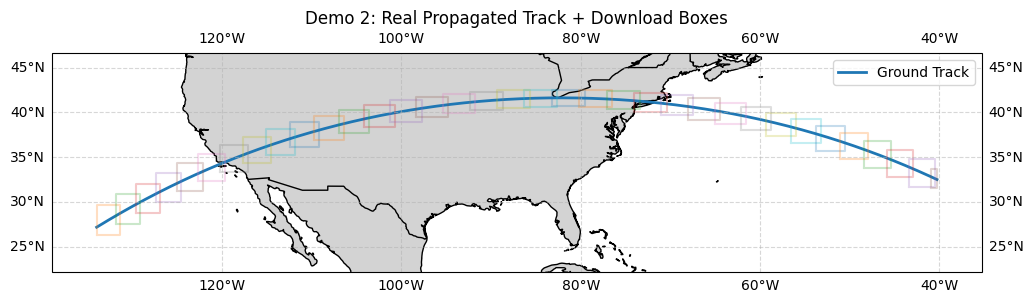

In [9]:
plot_track_and_boxes(
    track_points,
    box_windows=box_windows,
    title="Demo 2: Real Propagated Track + Download Boxes",
)

## Convert boxes into download requests

In [10]:
download_requests = box_windows_to_download_requests(box_windows)

print("Total download requests:", len(download_requests))
print("First request:")
print(download_requests[0])

Total download requests: 35
First request:
{'box_id': 'box_000', 'lat_min': 26.298501744448057, 'lat_max': 29.63771207120575, 'lon_min': np.float64(-133.9961980550119), 'lon_max': np.float64(-131.4027155898567), 't_start_utc': datetime.datetime(2024, 4, 2, 8, 38, tzinfo=datetime.timezone.utc), 't_end_utc': datetime.datetime(2024, 4, 2, 8, 53, 42, tzinfo=datetime.timezone.utc)}


## Optional quick-test subset

For a first run, it is safer to process only a few boxes.
Once that works, you can scale to the full set.

In [11]:
if quick_test:
    requests_to_run = download_requests[:quick_test_n_boxes]
else:
    requests_to_run = download_requests

print("Requests being run:", len(requests_to_run))

Requests being run: 15


## Save the request plan for reproducibility

In [12]:
requests_path = run_folder / "download_requests.json"

with open(requests_path, "w", encoding="utf-8") as f:
    json.dump(requests_to_run, f, indent=2, default=str)

print("Saved request plan to:", requests_path)

Saved request plan to: C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline\download_requests.json


## Run the library-backed download pipeline

This is the current real workflow:

box -> candidate inventory -> distance filter -> waveform download

In [13]:
manifest = download_boxes(
    download_requests=requests_to_run,
    track_points=track_points,
    output_base=output_base,
    event_name=event_name,
    corridor_km=corridor_km,
    providers=providers,
    channel_priorities=channel_priorities,
    location_priorities=location_priorities,
    overwrite_existing=False,
    verbose=True,
)

c:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\.venv\Lib\site-packages\obspy\clients\fdsn\client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


[1/15] processing box_000 ...
    inventory from IRIS: no data
    inventory from SCEDC: no data
    inventory from NCEDC: no data
    candidate stations: 0 | kept within 100 km: 0
[2/15] processing box_001 ...
    inventory from IRIS: no data
    inventory from SCEDC: no data
    inventory from NCEDC: no data
    candidate stations: 0 | kept within 100 km: 0
[3/15] processing box_002 ...
    inventory from IRIS: no data
    inventory from SCEDC: no data
    inventory from NCEDC: no data
    candidate stations: 0 | kept within 100 km: 0
[4/15] processing box_003 ...
    inventory from IRIS: no data
    inventory from SCEDC: no data
    inventory from NCEDC: no data
    candidate stations: 0 | kept within 100 km: 0
[5/15] skipping box_004 (already has data)
[6/15] skipping box_005 (already has data)
[7/15] skipping box_006 (already has data)
[8/15] skipping box_007 (already has data)
[9/15] skipping box_008 (already has data)
[10/15] skipping box_009 (already has data)
[11/15] skipping 

## Inspect the manifest

In [14]:
print("Manifest keys:", manifest.keys())
print("Total requests:", manifest["total_requests"])
print("OK:", manifest["ok"])
print("Skipped:", manifest["skipped_existing"])
print("Failed:", manifest["failed"])

Manifest keys: dict_keys(['event_name', 'run_folder', 'boxes_root', 'total_requests', 'providers', 'channel_priorities', 'location_priorities', 'corridor_km', 'ok', 'skipped_existing', 'failed', 'results'])
Total requests: 15
OK: 4
Skipped: 11
Failed: 0


In [15]:
for result in manifest["results"][:5]:
    print(json.dumps(result, indent=2, default=str))
    print("-" * 80)

{
  "box_id": "box_000",
  "status": "ok",
  "candidate_station_count": 0,
  "filtered_station_count": 0,
  "mseed_files": 0,
  "stationxml_files": 0,
  "waveform_results": []
}
--------------------------------------------------------------------------------
{
  "box_id": "box_001",
  "status": "ok",
  "candidate_station_count": 0,
  "filtered_station_count": 0,
  "mseed_files": 0,
  "stationxml_files": 0,
  "waveform_results": []
}
--------------------------------------------------------------------------------
{
  "box_id": "box_002",
  "status": "ok",
  "candidate_station_count": 0,
  "filtered_station_count": 0,
  "mseed_files": 0,
  "stationxml_files": 0,
  "waveform_results": []
}
--------------------------------------------------------------------------------
{
  "box_id": "box_003",
  "status": "ok",
  "candidate_station_count": 0,
  "filtered_station_count": 0,
  "mseed_files": 0,
  "stationxml_files": 0,
  "waveform_results": []
}
---------------------------------------------

## Locate the written box folders

In [16]:
run_folder = Path(manifest["run_folder"])
boxes_root = Path(manifest["boxes_root"])

print("Run folder:", run_folder)
print("Boxes root:", boxes_root)
print("Exists:", boxes_root.exists())

Run folder: C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline
Boxes root: C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline\boxes
Exists: True


## Load StationXML output and apply the library station filter globally

This gives a clean view of:
- all deduplicated candidate stations discovered across the processed boxes
- stations within the physical corridor around the track

In [17]:
station_result = load_and_filter_stations(
    boxes_root=boxes_root,
    track_points=track_points,
    corridor_km=corridor_km,
    verbose=True,
)

all_station_rows = station_result["all_station_rows"]
unique_stations = station_result["unique_stations"]
filtered_stations = station_result["filtered_stations"]

print("All parsed station rows:", len(all_station_rows))
print("Unique stations:", len(unique_stations))
print("Filtered stations:", len(filtered_stations))

StationXML files found: 21
Unique stations (downloaded candidates): 448
Stations within 100 km of track: 223 / 448
All parsed station rows: 1440
Unique stations: 448
Filtered stations: 223


## Plot candidate vs filtered stations

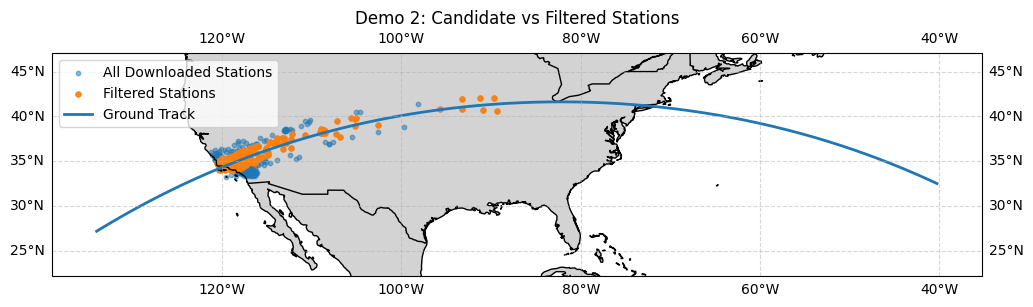

In [18]:
plot_station_comparison(
    unique_stations,
    filtered_stations,
    track_points=track_points,
    title="Demo 2: Candidate vs Filtered Stations",
)

## Plot filtered stations with the track and processed boxes

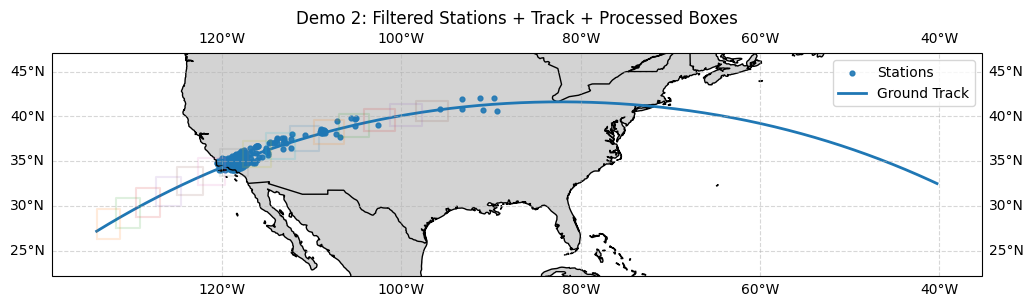

In [19]:
plot_stations(
    filtered_stations,
    track_points=track_points,
    box_windows=box_windows[:len(requests_to_run)],
    title="Demo 2: Filtered Stations + Track + Processed Boxes",
)

## Inspect files on disk

In [20]:
xml_files = sorted(boxes_root.rglob("stations/*.xml"))
mseed_files = sorted(boxes_root.rglob("waveforms/*.mseed"))

print("StationXML files found:", len(xml_files))
print("MiniSEED files found:", len(mseed_files))

print("\nFirst few StationXML files:")
for p in xml_files[:10]:
    print(p)

print("\nFirst few MiniSEED files:")
for p in mseed_files[:10]:
    print(p)

StationXML files found: 21
MiniSEED files found: 307

First few StationXML files:
C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline\boxes\box_004\stations\IRIS_stations.xml
C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline\boxes\box_004\stations\NCEDC_stations.xml
C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline\boxes\box_004\stations\SCEDC_stations.xml
C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline\boxes\box_005\stations\IRIS_stations.xml
C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline\boxes\box_005\stations\NCEDC_stations.xml
C:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\data\demo_outputs\demo_2_full_pipeline\boxes\box_005\stations\SCEDC_stations.xml
C:\Users\josep

## Optional: inspect one waveform

1 Trace(s) in Stream:
CI.ABL..HHZ | 2024-04-02T08:40:48.000000Z - 2024-04-02T08:56:30.000000Z | 100.0 Hz, 94201 samples
Trace ID: CI.ABL..HHZ
Start: 2024-04-02T08:40:48.000000Z
End: 2024-04-02T08:56:30.000000Z
Sampling rate: 100.0


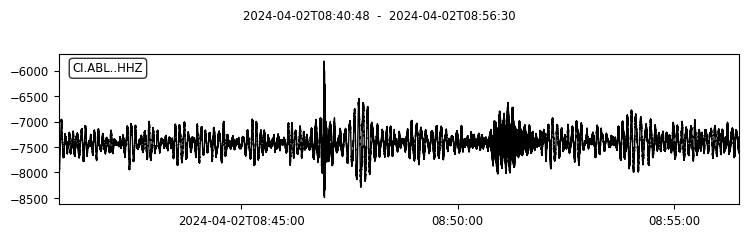

In [21]:
from obspy import read

if len(mseed_files) == 0:
    print("No waveform files found yet.")
else:
    st = read(str(mseed_files[0]))
    print(st)

    tr = st[0]
    print("Trace ID:", tr.id)
    print("Start:", tr.stats.starttime)
    print("End:", tr.stats.endtime)
    print("Sampling rate:", tr.stats.sampling_rate)

    tr.plot()

## Summary

This demo validated the current full library-backed workflow:

- NORAD ID -> TLE cache / fetch
- TLE -> propagated ground track
- propagated track -> box generation
- boxes -> download requests
- per-box candidate inventory queries
- distance-based station filtering
- waveform download for filtered stations only
- plotting of the resulting metadata products

A later refinement will revisit waveform-request merging across overlapping boxes to improve speed and reduce duplicate acquisition.